In [1]:
import numpy as np
import pandas as pd
import re
import sqlite3
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertModel
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../../data/all_tweets.db')

df = pd.read_sql_query("SELECT * FROM hashtags", conn)

print(df.head())

conn.close()


              tweet_id hashtags  \
0  1000000010413539328            
1  1000000018231844864            
2  1000000038628724736            
3  1000000062217334786            
4  1000000086296817664            

                               text_without_hashtags  likes  retweets  \
0  Leadership comes from your Heart. How to Lead ...      0         0   
1                            Jij hebt geen slakken 😑      0         0   
2  No te preocupes la segunda parte te la enseñam...     74        12   
3  6/15(金)代官山LOOPでの「仮谷お客様感謝デー」ライブより！ 仮谷せいらライブ会場限定...     73        37   
4                    ありがとうございます😊 いつでもお待ちしてます(`･ω･´)ゞ      1         0   

   replies  quotes  
0        0       0  
1        1       0  
2        0       1  
3        2       2  
4        0       0  


In [5]:
df['hashtags'] = df['hashtags'].replace(r'^\s*$', np.nan, regex=True)

In [6]:
df["hashtags"].value_counts()

hashtags
peing,質問箱                                                                 7029
Repost                                                                    5489
concert                                                                   4040
1                                                                         3835
Vimeo                                                                     3745
                                                                          ... 
streetart,laughing,pigasus,arteverywhere,whenpigsfly,underbelliesabove       1
musicislife,livemusicisbest,jointherevival                                   1
MorikamiMuseum,妖怪,物の怪,お化け,化け物,DailyJapanCulture                              1
UNSC,DRC,Haiti,Iraq,ISIL,Daesh,UNSCR1325                                     1
TestMasivosYa                                                                1
Name: count, Length: 1877360, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9850000 entries, 0 to 9849999
Data columns (total 7 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   tweet_id               object
 1   hashtags               object
 2   text_without_hashtags  object
 3   likes                  int64 
 4   retweets               int64 
 5   replies                int64 
 6   quotes                 int64 
dtypes: int64(4), object(3)
memory usage: 526.0+ MB


In [8]:
df.describe()

,likes,retweets,replies,quotes
count,9.850000e+06,9.850000e+06,9.850000e+06,9.850000e+06
mean,2.307591e+02,4.062970e+01,7.225587e+00,3.695494e+00
std,4.746943e+03,1.007725e+03,1.859030e+02,1.625683e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
max,2.582228e+06,5.965740e+05,1.112410e+05,1.505240e+05


In [9]:
# Step 1: Drop rows with any null values
df_clean = df.dropna()

In [10]:
df_clean

,tweet_id,hashtags,text_without_hashtags,likes,retweets,replies,quotes
6,1000000100339453954,AkashicIntegrationBlog,I realized that even though I was keeping trac...,0,0,0,0
15,1000000314907484161,business,The traits that drive startup founders forward...,0,0,0,0
17,1000000359136448512,"multimedia,video,web,print,audio,podcasts,webs...",Happy Memorial Day Weekend! #multimedia #video...,0,0,0,0
18,1000000372650409985,"CannesLions,onup",Looking forward to Susan Johnson David Oyelowo...,6,4,1,0
21,1000000433786703872,HOBYMD2018,We couldn't do our seminar without the amazing...,4,0,0,0
...,...,...,...,...,...,...,...
9849980,1241474749466722304,"JaredLetoCinemaClub,ferrisbuellersdayoff",Everyone join me in wishing Matthew Broderick ...,573,65,117,11
9849991,1241474917612347399,"diybio,PIHomeLab",Still some work to do (like adding safety feat...,25,1,0,0
9849992,1241474919839473666,"CoronavirusPandemic,xbox,GhostRecon",Not going to lie. I haven't turned on my Xbox ...,0,0,0,0
9849995,1241474952085278726,"worldpoetryday,acceptance,love","On this , let's create and",2,2,0,0


In [11]:
df_clean[df_clean['hashtags'].isnull()]

,tweet_id,hashtags,text_without_hashtags,likes,retweets,replies,quotes


In [13]:
df_clean[df_clean['hashtags'].str.strip() == ""]

,tweet_id,hashtags,text_without_hashtags,likes,retweets,replies,quotes


In [45]:
n_percent = 5  # Desired percentage

# Sort by likes descending and get top N%
top_n_count = int(len(df_clean) * n_percent / 100)
top_df = df_clean.sort_values(by='likes', ascending=False).head(top_n_count)

# Select only hashtags and likes columns (optional)
top_hashtags_with_likes = top_df[['hashtags', 'text_without_hashtags', 'likes']]

In [46]:
top_hashtags_with_likes

,hashtags,text_without_hashtags,likes
8814298,33644,Continuing to move the game forward . Much res...,2582228
6446100,JUNGKOOK,Happy bday #JUNGKOOK . They ain’t ready :) now...,1282252
8490296,2020,first selfie of the year doe.,856725
1257133,JustDoIt,"Believe in something, even if it means sacrifi...",794709
6364075,InternationalDogDay,Happy #InternationalDogDay,726883
...,...,...,...
8616069,"conservativeHipHop,MAGAS,TRUMP2020,Cult45",You ain’t NEVER heard on this level!! All you...,172
9515798,unco2020,"A wife turns to her husband and says, “How com...",172
1405624,"FridayFeeling,FlashbackFriday",Getting to the weekend like... 😎 #FridayFeelin...,172
1477068,SophiaLoren,"Oggi tre donne italiane forti, brillanti e car...",172


In [49]:
top_hashtags_with_likes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161542 entries, 8814298 to 3336136
Data columns (total 3 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   hashtags               161542 non-null  object
 1   text_without_hashtags  161542 non-null  object
 2   likes                  161542 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB


In [51]:
top_hashtags_with_likes.describe()

,likes
count,1.615420e+05
mean,3.626536e+03
std,1.551287e+04
min,1.720000e+02
25%,3.150000e+02
50%,6.820000e+02
75%,2.101000e+03
max,2.582228e+06


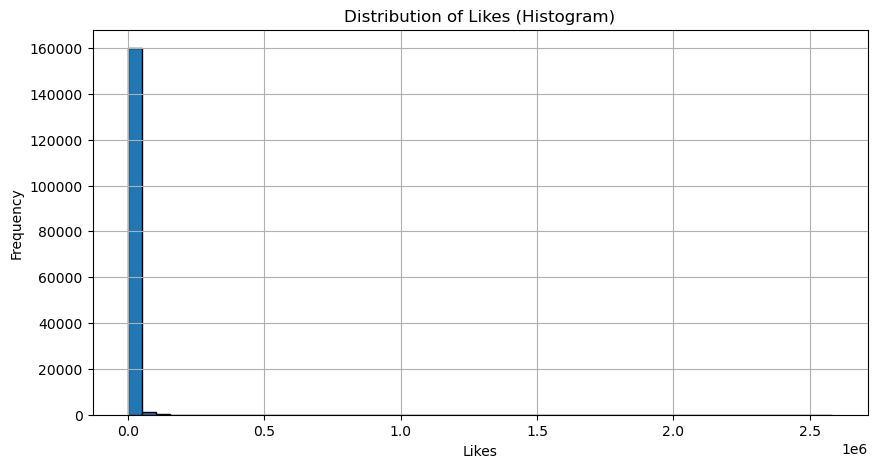

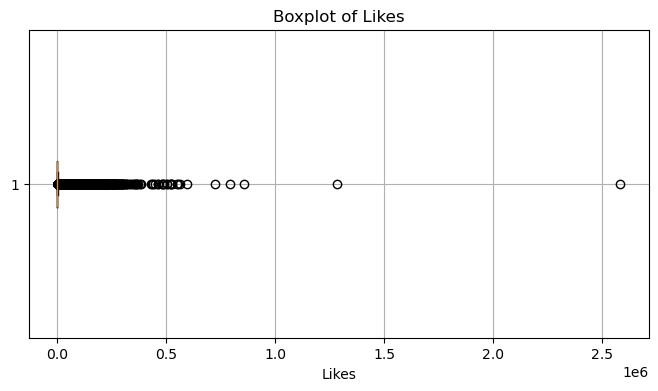

In [53]:
import matplotlib.pyplot as plt

# Plot Histogram
plt.figure(figsize=(10, 5))
plt.hist(top_hashtags_with_likes['likes'], bins=50, edgecolor='black')
plt.title('Distribution of Likes (Histogram)')
plt.xlabel('Likes')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot Boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(top_hashtags_with_likes['likes'], vert=False)
plt.title('Boxplot of Likes')
plt.xlabel('Likes')
plt.grid(True)
plt.show()


In [61]:
import pandas as pd

# Calculate IQR
Q1 = top_hashtags_with_likes['likes'].quantile(0.25)
Q3 = top_hashtags_with_likes['likes'].quantile(0.75)
IQR = Q3 - Q1

# Define upper bound (you can tweak the multiplier 1.5 → 2.0 for strictness)
upper_bound = Q3 + 1.5 * IQR

# Filter
df_filtered = top_hashtags_with_likes[top_hashtags_with_likes['likes'] <= upper_bound].reset_index(drop=True)


In [63]:
import re

def clean_text(text):
    text = re.sub(r"#\w+", "", text)  # remove hashtags
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)  # remove mentions
    text = re.sub(r"\n", " ", text)
    return re.sub(r'\s+', ' ', text).strip()

df_filtered['clean_text'] = df_filtered['text_without_hashtags'].apply(clean_text)


In [65]:

df_filtered.head()

,hashtags,text_without_hashtags,likes,clean_text
0,"NeverAgain,YomHaShoah","In February, &amp; I traveled to Poland &amp; ...",4780,"In February, &amp; I traveled to Poland &amp; ..."
1,TheGirlOnTheTrain,The most thrilling ride of my life!!! Guyssss ...,4780,The most thrilling ride of my life!!! Guyssss ...
2,hq_anime,3/18(水)発売「ハイキュー!! TO THE TOP」BD&amp;DVD Vol.1の...,4779,3/18(水)発売「ハイキュー!! TO THE TOP」BD&amp;DVD Vol.1の...
3,PeakyBlinders,Cillian Murphy and #PeakyBlinders have made th...,4778,Cillian Murphy and have made the cover of 📝 📸
4,"GARTHatND,GARTHatND","If YOU are watching the special with us, tweet...",4776,"If YOU are watching the special with us, tweet..."


In [67]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139598 entries, 0 to 139597
Data columns (total 4 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   hashtags               139598 non-null  object
 1   text_without_hashtags  139598 non-null  object
 2   likes                  139598 non-null  int64 
 3   clean_text             139598 non-null  object
dtypes: int64(1), object(3)
memory usage: 4.3+ MB


In [68]:
df_filtered.describe()

,likes
count,139598.000000
mean,969.441546
std,1002.670392
min,172.000000
25%,287.000000
50%,545.000000
75%,1243.000000
max,4780.000000


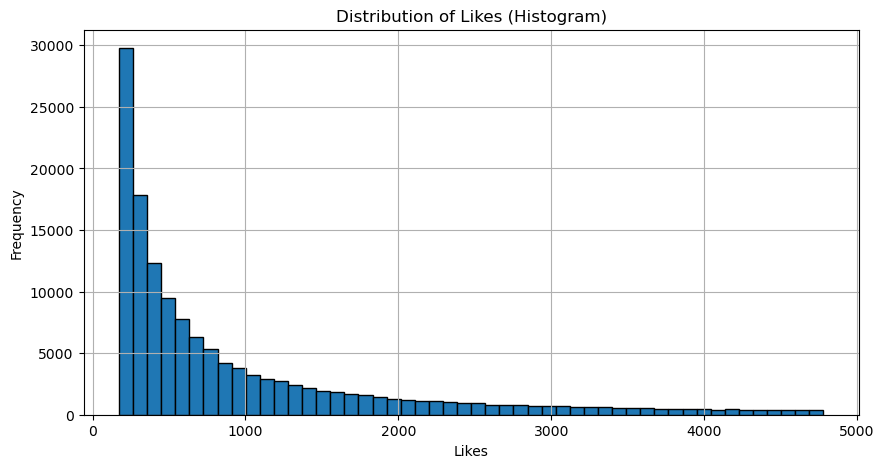

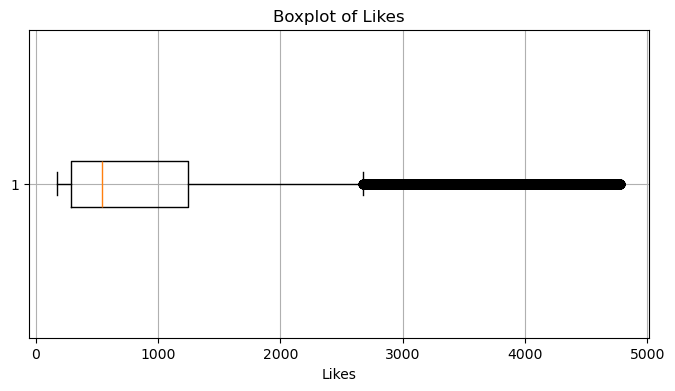

In [71]:
import matplotlib.pyplot as plt

# Plot Histogram
plt.figure(figsize=(10, 5))
plt.hist(df_filtered['likes'], bins=50, edgecolor='black')
plt.title('Distribution of Likes (Histogram)')
plt.xlabel('Likes')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot Boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(df_filtered['likes'], vert=False)
plt.title('Boxplot of Likes')
plt.xlabel('Likes')
plt.grid(True)
plt.show()

In [79]:
df_filtered['likes_log'] = np.log1p(df_filtered['likes'])

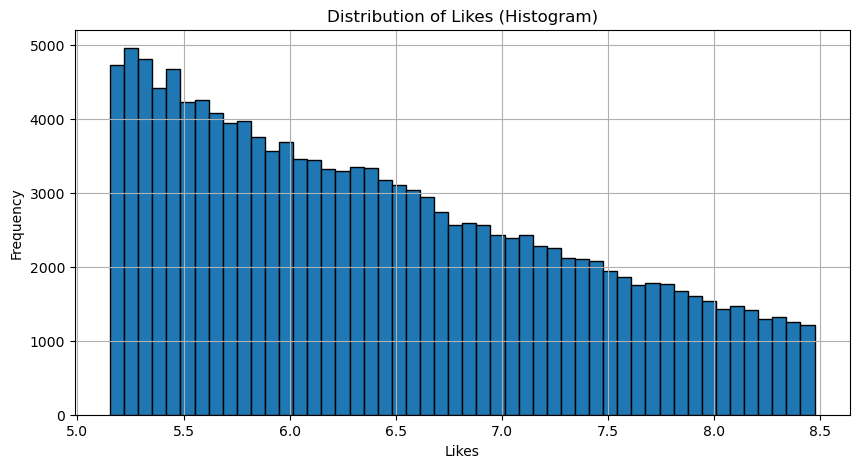

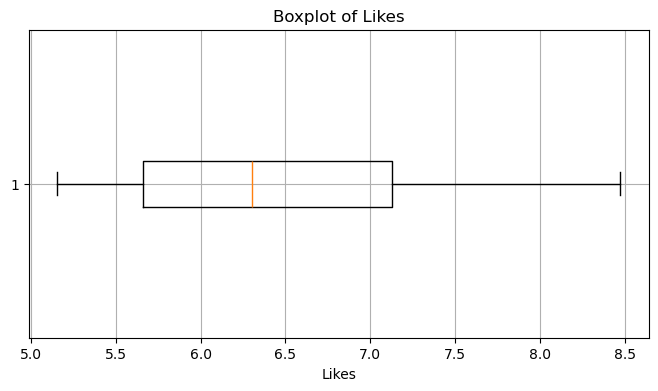

In [81]:
import matplotlib.pyplot as plt

# Plot Histogram
plt.figure(figsize=(10, 5))
plt.hist(df_filtered['likes_log'], bins=50, edgecolor='black')
plt.title('Distribution of Likes (Histogram)')
plt.xlabel('Likes')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot Boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(df_filtered['likes_log'], vert=False)
plt.title('Boxplot of Likes')
plt.xlabel('Likes')
plt.grid(True)
plt.show()

In [83]:
df_filtered = df_filtered[df_filtered['hashtags'].notnull() & (df_filtered['hashtags'].str.strip() != "")]
df_filtered['hashtags_target'] = df_filtered['hashtags'].apply(lambda x: x.replace(" ", "").strip())

In [85]:
df_filtered

,hashtags,text_without_hashtags,likes,clean_text,likes_log,hashtags_target
0,"NeverAgain,YomHaShoah","In February, &amp; I traveled to Poland &amp; ...",4780,"In February, &amp; I traveled to Poland &amp; ...",8.472405,"NeverAgain,YomHaShoah"
1,TheGirlOnTheTrain,The most thrilling ride of my life!!! Guyssss ...,4780,The most thrilling ride of my life!!! Guyssss ...,8.472405,TheGirlOnTheTrain
2,hq_anime,3/18(水)発売「ハイキュー!! TO THE TOP」BD&amp;DVD Vol.1の...,4779,3/18(水)発売「ハイキュー!! TO THE TOP」BD&amp;DVD Vol.1の...,8.472196,hq_anime
3,PeakyBlinders,Cillian Murphy and #PeakyBlinders have made th...,4778,Cillian Murphy and have made the cover of 📝 📸,8.471987,PeakyBlinders
4,"GARTHatND,GARTHatND","If YOU are watching the special with us, tweet...",4776,"If YOU are watching the special with us, tweet...",8.471568,"GARTHatND,GARTHatND"
...,...,...,...,...,...,...
139593,"conservativeHipHop,MAGAS,TRUMP2020,Cult45",You ain’t NEVER heard on this level!! All you...,172,You ain’t NEVER heard on this level!! All you ...,5.153292,"conservativeHipHop,MAGAS,TRUMP2020,Cult45"
139594,unco2020,"A wife turns to her husband and says, “How com...",172,"A wife turns to her husband and says, “How com...",5.153292,unco2020
139595,"FridayFeeling,FlashbackFriday",Getting to the weekend like... 😎 #FridayFeelin...,172,Getting to the weekend like... 😎,5.153292,"FridayFeeling,FlashbackFriday"
139596,SophiaLoren,"Oggi tre donne italiane forti, brillanti e car...",172,"Oggi tre donne italiane forti, brillanti e car...",5.153292,SophiaLoren


In [87]:
from langdetect import detect, DetectorFactory
import pandas as pd
from tqdm import tqdm

DetectorFactory.seed = 0  # make detection consistent

# Optional: tqdm for progress bar
tqdm.pandas()

def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

# Filter the DataFrame
df_english = df_filtered[df_filtered['text_without_hashtags'].progress_apply(is_english)].reset_index(drop=True)

100%|██████████████████████████████████| 139598/139598 [02:42<00:00, 857.50it/s]


In [89]:
df_english 

,hashtags,text_without_hashtags,likes,clean_text,likes_log,hashtags_target
0,"NeverAgain,YomHaShoah","In February, &amp; I traveled to Poland &amp; ...",4780,"In February, &amp; I traveled to Poland &amp; ...",8.472405,"NeverAgain,YomHaShoah"
1,TheGirlOnTheTrain,The most thrilling ride of my life!!! Guyssss ...,4780,The most thrilling ride of my life!!! Guyssss ...,8.472405,TheGirlOnTheTrain
2,PeakyBlinders,Cillian Murphy and #PeakyBlinders have made th...,4778,Cillian Murphy and have made the cover of 📝 📸,8.471987,PeakyBlinders
3,"GARTHatND,GARTHatND","If YOU are watching the special with us, tweet...",4776,"If YOU are watching the special with us, tweet...",8.471568,"GARTHatND,GARTHatND"
4,KingdomHearts,"To celebrate the one year anniversary of III,...",4776,"To celebrate the one year anniversary of III, ...",8.471568,KingdomHearts
...,...,...,...,...,...,...
76067,AbuDhabi,Thank you to all our sponsors for making #AbuD...,172,Thank you to all our sponsors for making show ...,5.153292,AbuDhabi
76068,IIFA2018,Looking forward to the telecast of #IIFA2018 t...,172,Looking forward to the telecast of tonight at ...,5.153292,IIFA2018
76069,"conservativeHipHop,MAGAS,TRUMP2020,Cult45",You ain’t NEVER heard on this level!! All you...,172,You ain’t NEVER heard on this level!! All you ...,5.153292,"conservativeHipHop,MAGAS,TRUMP2020,Cult45"
76070,unco2020,"A wife turns to her husband and says, “How com...",172,"A wife turns to her husband and says, “How com...",5.153292,unco2020


In [101]:
import pandas as pd
import os
from datasets import Dataset
from transformers import (
    T5Tokenizer, T5ForConditionalGeneration, Trainer,
    TrainingArguments, DataCollatorForSeq2Seq, EarlyStoppingCallback
)

# === CONFIG ===
MODEL_NAME = "t5-small"
SAVE_EVERY = 10000  # save every 10k examples
EPOCHS = 3
CHECKPOINT_DIR = "checkpoints"

# === LOAD DATA ===
# df = pd.read_csv("data.csv")
# df = df[df['hashtags_target'].notnull() & (df['hashtags_target'].str.strip() != "")]
df = df_english
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

def preprocess_function(example):
    input_text = "generate hashtags: " + example["clean_text"]
    model_input = tokenizer(input_text, max_length=128, truncation=True, padding="max_length")
    target = tokenizer(example["hashtags_target"], max_length=32, truncation=True, padding="max_length")
    model_input["labels"] = target["input_ids"]
    return model_input

# === CHUNK AND TRAIN ===
for i in range(0, len(df), SAVE_EVERY):
    chunk = df.iloc[i:i+SAVE_EVERY]
    step = i + SAVE_EVERY
    chunk_ds = Dataset.from_pandas(chunk[['clean_text', 'hashtags_target']])
    chunk_ds = chunk_ds.map(preprocess_function)

    model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

    training_args = TrainingArguments(
        output_dir=f"{CHECKPOINT_DIR}/step-{step}",
        per_device_train_batch_size=8,
        num_train_epochs=EPOCHS,
        logging_dir=f"{CHECKPOINT_DIR}/logs/step-{step}",
        logging_steps=50,
        save_total_limit=1,
        save_strategy="no",  # we manually save with push_to_hub/save_pretrained
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=chunk_ds,
        tokenizer=tokenizer,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model)
    )

    trainer.train()
    model.save_pretrained(f"{CHECKPOINT_DIR}/step-{step}")
    tokenizer.save_pretrained(f"{CHECKPOINT_DIR}/step-{step}")
    print(f"✅ Saved model at step {step}")


ImportError: 
T5Tokenizer requires the SentencePiece library but it was not found in your environment. Checkout the instructions on the
installation page of its repo: https://github.com/google/sentencepiece#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


In [103]:
df_english.to_pickle("df_english.pkl")

